In [104]:
from dataclasses import dataclass
import torch
import torch.nn as nn
import configparser
from pathlib import Path
import requests
import unicodedata
import numpy as np
import kagglehub
import csv
import pandas as pd
from collections import Counter, defaultdict
import json
import base64

from IPython.display import Image, display
from jaxtyping import Int, Float
import matplotlib.pyplot as plt

import os.path
from os import path

In [105]:
print(torch.__version__)

2.5.1+cpu


In [106]:
@dataclass
class Config: 
    d_model:int
    d_vocab:int
    d_hidden:int
    d_head:int
    t_blocks:int
    nc:int
    seed:int

In [107]:
class MLP(nn.Module):
            def __init__(self,config):
                super().__init__()
                self.gelu = nn.GELU()
                self.fc1 = nn.Linear(config.d_model, config.d_hidden)
                self.fc2 = nn.Linear(config.d_hidden,config.d_model)

            def forward(self, x):
                x = self.gelu(self.fc1(x))
                x = self.fc2(x)
                return x

class AttentionHead(nn.Module):
    def __init__(self,config:Config):
         super().__init__()
         self.WQ = nn.Linear(config.d_model,config.d_head) #W_Q
         self.WK = nn.Linear(config.d_model,config.d_head) 
         self.WOV =nn.Linear(config.d_model,config.d_model)
         self.SM = nn.Softmax(dim=-1)

    def forward(self,x):
        nc = x.size(1)
        fullM = torch.full(size = (nc,nc),fill_value= float("-Inf"))
        maskM = torch.triu(fullM, diagonal=1)

        left_mult = self.WQ(x)
        right_mult = torch.transpose(self.WK(x),-2,-1)
        activation_input = left_mult @ right_mult + maskM
        acitvation_output = self.SM(activation_input)

        return acitvation_output  @ self.WOV(x)


class TransformerBlock(nn.Module):
    def __init__(self,config:Config):
        super().__init__()
        self.AH1 = AttentionHead(config)
        self.MLP = MLP(config)

    def forward(self,x):
        attention_sum = x + self.AH1(x)
        return  attention_sum +  self.MLP(attention_sum)
    
class TransformerArchitecture(nn.Module):
     def __init__(self,config:Config):
          super().__init__()
          self.EC = nn.Embedding(num_embeddings= config.d_vocab, embedding_dim= config.d_model)
          self.PC = nn.Embedding(num_embeddings=config.nc,embedding_dim= config.d_model)
          self.blocks = nn.ModuleList([TransformerBlock(config) for i in range(config.t_blocks)])
          self.UEMB = nn.Linear(config.d_model,config.d_vocab,bias= False) #Unembedding

     def forward(self,x):
        x = self.EC(x) + self.PC(torch.arange(x.size(1),device=x.device))
        for block in self.blocks:
             x = block(x)
             
        #return x @ self.EC.weight.T 
        return self.UEMB(x)

In [108]:
#DATA_RAW: list[str] = get_many_books([84, 15, 18, 82, 996, 2600])
# kagglehub.dataset_download("snap/amazon-fine-food-reviews")

In [109]:

data_path = "C:/Users/m10938457/Documents/LLMs/decoding-gpt/data/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2/Reviews.csv"
food_reviews = pd.read_csv(data_path)
food_review_text = food_reviews["Text"]

In [110]:
def process_text(
	text: str,
	allowed_punctuation: str = "-.,;:!?()\"" + "".join(str(x) for x in range(10)),
	punctuation_convert: dict[str,str] = {'—': '-'},
) -> str:
	
	# replace some special characters which unicode won't normalize properly
	for char, replacement in punctuation_convert.items():
		text = text.replace(char, replacement)

	# if a line has ".jpg" in it, remove that line (this is specific to Don Quixote)
	text = '\n'.join(
		line 
		for line in text.split('\n')
		if '.jpg' not in line
	)

	# Normalize the string to decompose Unicode characters
	text = unicodedata.normalize('NFKD', text)

	# Encode to ASCII bytes, then decode back to string, ignoring errors
	text = text.encode('ascii', 'ignore').decode('ascii')

	# remove newlines and tabs
	text = text.replace('\n', ' ').replace('\t', ' ')


	# put spaces around allowed punctuation
	for char in allowed_punctuation:
		text = text.replace(char, f' {char} ')


	# remove leading and trailing spaces
	text = text.strip()

	# remove multiple spaces
	while '  ' in text:
		text = text.replace('  ', ' ')


	# remove all characters except (alphanumeric, allowed_punctuation, ' ')
	text = ''.join(
		(
			char 
			if (
				char.isalnum() 
				or char in allowed_punctuation 
				or char == ' '
			)
			else ' '
		)
		for char in text 
	)

	# convert to lowercase
	text = text.lower()

	text = text.strip()

	return text

DATA: str = " ".join(process_text(x) for x in food_review_text)

In [111]:
def tokenize(
	text: str,
	process: bool = False,
) -> list[str]:
	if process:
		text = process_text(text)
	return text.split(' ')

DATA_TOKENIZED: list[str] = tokenize(DATA)

def analyze_vocab(
	tokenized_text: list[str],
) -> Counter[str]:

	vocab_freq: Counter[str] = Counter(tokenized_text)
	vocab_size: int = len(vocab_freq)

	# print(f"{vocab_size = }")
	# print(f"{vocab_freq.most_common(10) = }")
	# print(f"{vocab_freq.most_common()[-10:] = }")

	# get longest and shortest words
	vocab_length_sorted: list[str] = sorted(vocab_freq.keys(), key=len)
	# print(f"{vocab_length_sorted[-1000:] = }")
	# print(f"{vocab_length_sorted[-1000:] = }")

	# plot histogram of word frequencies
	# plt.figure(figsize=(10, 5))
	# plt.hist(np.log10(np.array(list(vocab_freq.values()))), bins=100, log=True)
	# plt.yscale('log')
	# plt.xlabel("log(Word frequency)")
	# plt.ylabel("Number of words")
	# plt.show()

	# plot histogram of word lengths
	word_lengths = np.array([len(x) for x in vocab_freq.keys()])
	# plt.figure(figsize=(10, 5))
	# plt.hist(word_lengths, bins=20, log=True)
	# plt.yscale('log')
	# plt.xlabel("Word length")
	# plt.ylabel("Number of words")
	# plt.title(f"Word length distribution\nmean = {word_lengths.mean():.2f}, median = {np.median(word_lengths):.2f}")
	# plt.show()

	return vocab_freq

VOCAB_FREQ: Counter[str] = analyze_vocab(DATA_TOKENIZED)

WORDS_BY_FREQ: dict[int, list[str]] = {
	freq: [
		word 
		for word, word_freq in VOCAB_FREQ.items() 
		if word_freq == freq
	]
	for freq in set(VOCAB_FREQ.values())
}

# for freq in range(1, 4):
# 	print(f"{len(WORDS_BY_FREQ[freq])} words with frequency {freq}")


In [112]:
# sorted by frequency
VOCAB_ARR: list[str] = [word for word, _ in VOCAB_FREQ.most_common()]
VOCAB_DICT: dict[str, int] = {word: i for i, word in enumerate(VOCAB_ARR)}

def encode(
	text: str|list[str],
) -> Int[np.ndarray, "n_tokens"]:
	if isinstance(text, str):
		text = tokenize(text)
	return np.array([VOCAB_DICT[word] for word in text])

def decode(
	encoded_text: list[int],
) -> str:
	return ' '.join(VOCAB_ARR[i] for i in encoded_text)

DATA_ENCODED: Int[np.ndarray, "n_tokens"] = encode(DATA)

print(f"{decode(DATA_ENCODED[-10:]) = }")


decode(DATA_ENCODED[-10:]) = 'with raw vinegar , and as a general sweetner .'


In [130]:
# Get the 1000 longest words (last 1000 in vocab_length_sorted)
words_to_exclude = set(VOCAB_ARR[-1000:])

# Filter both the encoded data and the original string positions
filtered_pairs = [
    (token, encoded)
    for token, encoded in zip(DATA_TOKENIZED, DATA_ENCODED)
    if token not in words_to_exclude
]

# Unzip back into separate lists
DATA_filtered, DATA_ENCODED_filtered = zip(*filtered_pairs) if filtered_pairs else ([], [])
DATA_filtered = list(DATA_filtered)
DATA_ENCODED_filtered = np.array(DATA_ENCODED_filtered)

In [131]:
def StackEncodedData(encodedData,config):
    #turn 1d encoded data to stacked dataset from 
    n_tokens = (len(encodedData)// config.nc) *config.nc
    return encodedData[:n_tokens].reshape(-1,config.nc)

In [132]:
def GetDataLoader(data, batch_size:int,config):
    tensor_data = torch.tensor(np.array(data),dtype = torch.long)
    generator = torch.Generator(device = torch.device('cpu'))
    generator.manual_seed(config.seed)
    loader = torch.utils.data.DataLoader(tensor_data,batch_size=batch_size,generator= generator,shuffle= True,drop_last= bool(batch_size < len(data)))
    
    return loader

In [133]:
def train(model,optim, loader, num_epochs,config):
    losses = []
    n_batches = len(loader)
    model.train()
    
    for epoch in range(num_epochs):
        for batch in loader:
            x_train = batch[:,:-1].long()
            y_train  = batch[:,1:].long()

            model_pred = model(x_train)
            
            loss = torch.nn.functional.cross_entropy(model_pred.transpose(1,2),y_train, ignore_index=-1)
            losses.append(loss.item())
            print('loss: ',loss)
            optim.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optim.step()
    return losses

In [134]:
def generate(model, prompt, config, max_new_tokens=100 ):

    model.eval()
    input_ids = torch.tensor(encode(prompt), dtype=torch.long).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):

            #input_cropped = input_ids[:, - config.nc:]
            
            # Get predictions
            logits = model(input_ids)  
            
            # Take logits at the last position
            logits = logits[:, -1, :]  # (1, vocab_size)
            
            # Convert to probabilities and sample
            probs = torch.nn.functional.softmax(logits,dim=-1)
            torch.random.manual_seed(config.seed)
            next_token = torch.multinomial(probs, num_samples=1)  # (1, 1)
            
            # Append to sequence and continue
            input_ids = torch.cat([input_ids, next_token], dim=1)
    
    return decode(input_ids[0].tolist())


In [135]:
curr_len = len(DATA_ENCODED_filtered) 
target_len = (int(curr_len * 1/(60)) //config.nc) *config.nc #training on a fifth of the data
#### Making dataset small enough

DATA_ENCODED_SUB = np.array(DATA_ENCODED_filtered[:target_len])

FILTERED_VOCAB = analyze_vocab(tokenize(decode(DATA_ENCODED_SUB)))

filtered_token_to_idx = {token: idx for idx, token in enumerate(FILTERED_VOCAB.keys())}

# Decode back to tokens then re-encode with filtered vocab
tokens = tokenize(decode(DATA_ENCODED_SUB))
DATA_ENCODED_FILTERED_REENCODED = np.array([filtered_token_to_idx[t] for t in tokens if t in filtered_token_to_idx])

DIM = int(np.sqrt(len(FILTERED_VOCAB.keys())))
print(DIM)

134


In [136]:

config = Config(
    d_model = DIM,
    d_vocab = len(FILTERED_VOCAB.keys()),
    d_hidden = DIM,
    d_head = int(DIM*0.4),
    t_blocks = 2,
    nc = 128,
    seed = 2026
)

In [137]:

REMY = TransformerArchitecture(config) #REMY from Ratatouille
UNTRAINED_EMILLE = TransformerArchitecture(config)

optim = torch.optim.AdamW(REMY.parameters(),lr=1e-2,fused = True)
DATA_2D = StackEncodedData(DATA_ENCODED_FILTERED_REENCODED,config)
DATA_2D = torch.tensor(DATA_2D,dtype= torch.long)
loader = GetDataLoader(DATA_2D,32,config)

model_loss1 = train(REMY,optim,loader,1,config)

loss:  tensor(10.3142, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(9.3611, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(14.9316, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(7.3353, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(7.3884, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(7.3867, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(7.3078, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(7.2244, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(7.1420, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.9427, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.8896, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.8420, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.8169, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.5855, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.5705, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.5875, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.5880, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.3863, grad_fn=<NllLoss2DBackward0>)
loss:  tensor(6.6003, grad_fn=<NllLoss2DBackward0>)
loss:  ten

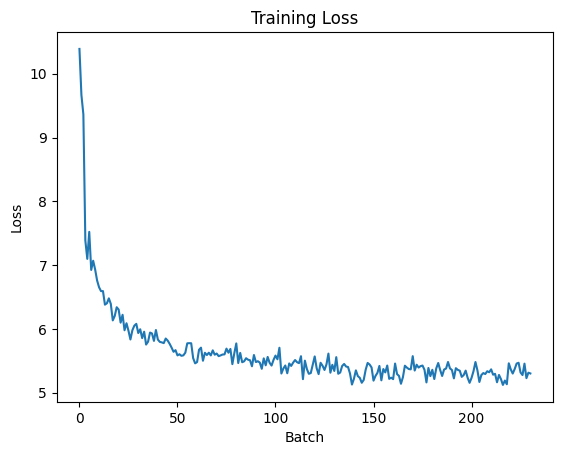

In [ ]:
plt.plot(model_loss1)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
print(generate(REMY,config=config, prompt= "my favorite food is"))
print(generate(UNTRAINED_EMILLE,config=config, prompt= "my favorite food is"))

my favorite food is artificial samples samples samples samples samples samples samples samples samples samples samples samples samples samples samples samples samples artificial samples i samples fun four samples samples but percent samples i know samples samples i buying artificial but percent samples i and fun samples samples samples samples samples samples but nut fun ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago ago i samples i know discount i samples i know i samples samples samples but nut know samples samples but
my favorite food is four four four four four four four four four four four four four four four four four four four four four four four four four confusion four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four four